# 24장 트랜스포머 직접 만들어 보기

트랜스포머를 이용하면 번역, 텍스트 생성, 문서 요약, 질의 응답, 감정 분석, 음성 및 이미지, 코드 자동 완성 및 생성등을 하는  AI프로그램을 만들 수 있다.<br />
언어에서는 다음 예 처럼 순서가 중요하다는 것을 알 수 가 있다<br />
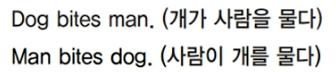<br />
어순에 따라서 완전히 다른 내용이 된다는 것을 알 수 있다.<br />
어텐션만으로는 언어의 순서를 딸 달라지는 것을 판단할 수 없어 positional Encodeing을 사용하여 언어의 순서를 기억할 수 있게 했는데 이것을 트랜스퍼머라고 한다.<br />
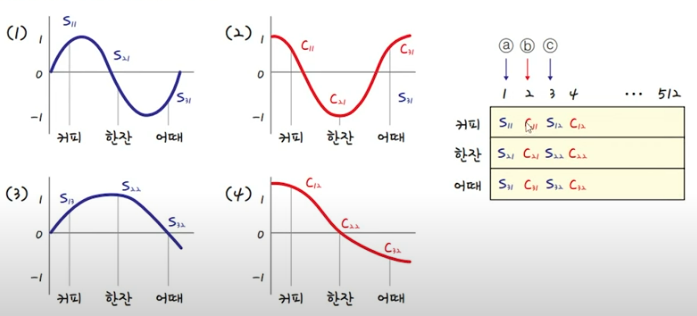<br />
위 그림 처럼 같은 문장이어도 각 단어에 위치정보를 위치정보를 sin(사인)값과 cos(코사인) 값으로 저장하여 position을 정해 어텐션으로 저장한다.<br />
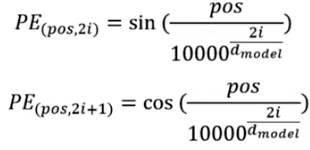<br />
사인값과 코사인값이 저장되는 공식이다.<br />
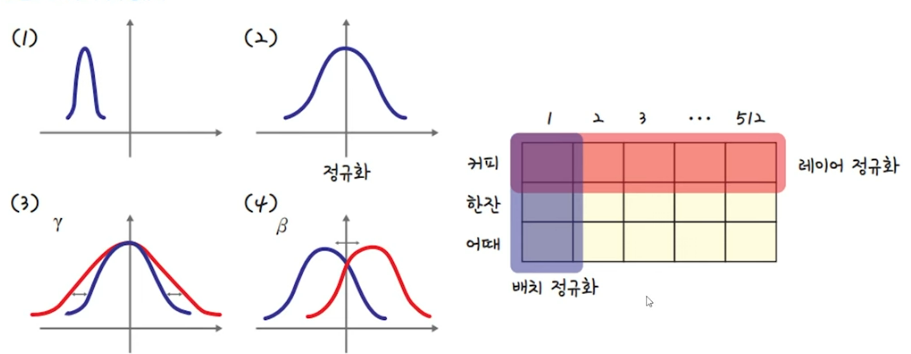<br />
정규화 과정을 거치는데 감마와 베타라는 과정을 거치는 정규화 관정을 거치게 된다.

## 트랜스포머 인코더를 활용한 긍정 부정 예측


In [7]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Embedding, GlobalAveragePooling1D, LayerNormalization, Dropout, Add, Input
from tensorflow.keras.optimizers import Adam
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# CSV 파일 로드
dataframe = pd.read_csv('https://raw.githubusercontent.com/SoongMoo/data/refs/heads/main/sentiment_data.csv')
# 긍정평가와 부정 평가가 2000개가 있다.

# 데이터와 라벨 추출
sentences = dataframe['sentence'].tolist()  # 내용만 가져옴
labels = dataframe['label'].tolist() # 부정과 긍정인 결과를 가져옴

# 임베딩 벡터 크기와 최대 문장 길이 설정
embedding_dim = 128  
max_len = 10  # 글자의 갯수

# 토크나이저 초기화 및 텍스트를 시퀀스로 변환
tokenizer = tf.keras.preprocessing.text.Tokenizer() # 공백문자를 기준으로  단어를 구분한다.
tokenizer.fit_on_texts(sentences) # sentences를 이용해서 fit(학습)을 한다.
'''
sentences 안에 있는 모든 단어를 스캔해서 단어 사전(word_index) 을 만든다.
예를 들어
sentences = ["커피 한잔 어때", "오늘 날씨 좋아"]
word_index = {"커피":1, "한잔":2, "어때":3, "오늘":4, "날씨":5, "좋아":6}
'''

sequences = tokenizer.texts_to_sequences(sentences)
'''
["커피 한잔 어때"] → [1, 2, 3]
["오늘 날씨 좋아"] → [4, 5, 6]
라면 sequences를 다음과 같이 만들어준다. 
sequences = [[1, 2, 3], [4, 5, 6]]

'''

word_index = tokenizer.word_index # 입력데이터가 된다.
'''
sentences = ["커피 한잔 어때", "오늘 날씨 좋아"]
sentences가 위와 같을 때 
{'커피': 1, '한잔': 2, '어때': 3, '오늘': 4, '날씨': 5, '좋아': 6}
문장의 단어에 index값을 갖게 된다.
'''

# 패딩을 사용하여 시퀀스 길이를 동일하게 맞춤
data = tf.keras.preprocessing.sequence.pad_sequences(sequences, maxlen=max_len, padding='post')
# 문장의 길이가 다른 경우 pad_sequences를 사용해 같은 길이로 맞춰주는 과정을 한다
# padding='post'은 뒤쪽에 0으로 채움
'''
sequences = [[1, 2, 3], [4, 5], [6]]
max_len = 5
라고한다면 data 변수 값은 아래와 같게 된다.
[[1 2 3 0 0]
 [4 5 0 0 0]
 [6 0 0 0 0]]
'''

# 데이터셋을 훈련 세트와 검증 세트로 분리
X_train, X_val, y_train, y_val = train_test_split(data, labels, test_size=0.2, random_state=42)

# 포지셔널 인코딩 함수
def get_positional_encoding(max_len, d_model):
    pos_enc = np.zeros((max_len, d_model))
    for pos in range(max_len):
        for i in range(0, d_model, 2):
            pos_enc[pos, i] = np.sin(pos / (10000 ** (2 * i / d_model)))
            if i + 1 < d_model:
                pos_enc[pos, i + 1] = np.cos(pos / (10000 ** (2 * (i + 1) / d_model)))
    return pos_enc

# 포지셔널 인코딩 생성
positional_encoding = get_positional_encoding(max_len, embedding_dim)

# 멀티헤드 어텐션 레이어 (마스크 미사용)
class MultiHeadSelfAttentionLayer(tf.keras.layers.Layer):
    def __init__(self, num_heads, key_dim):
        super(MultiHeadSelfAttentionLayer, self).__init__()
        self.mha = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)
        self.norm = LayerNormalization()

    def call(self, x):
        attn_output = self.mha(query=x, value=x, key=x)
        attn_output = self.norm(attn_output + x)
        return attn_output

# 모델 설정
inputs = Input(shape=(max_len,))

# 1. 임베딩 레이어
embedding_layer = Embedding(input_dim=len(word_index) + 1, output_dim=embedding_dim)
embedded_sequences = embedding_layer(inputs)

# 2. 포지셔널 인코딩 추가
embedded_sequences_with_positional_encoding = embedded_sequences + positional_encoding

# 3. 첫 번째 멀티헤드 어텐션 (마스크 없음)
attention_layer = MultiHeadSelfAttentionLayer(num_heads=8, key_dim=embedding_dim)
attention_output = attention_layer(embedded_sequences_with_positional_encoding)

# 4. 잔차 연결
attention_output_with_residual = Add()([embedded_sequences_with_positional_encoding, attention_output])

# 5. GlobalAveragePooling1D
pooled_output = GlobalAveragePooling1D()(attention_output_with_residual)

# 6. 피드 포워드 네트워크
dense_layer = Dense(128, activation='relu')(pooled_output)
dropout_layer = Dropout(0.5)(dense_layer)
output_layer = Dense(1, activation='sigmoid')(dropout_layer)

model = Model(inputs=inputs, outputs=output_layer)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.fit(X_train, np.array(y_train), epochs=10, batch_size=16, validation_data=(X_val, np.array(y_val)))

# 새 문장 예측
sample_texts = ["I absolutely love this!", "I can't stand this product"]
sample_sequences = tokenizer.texts_to_sequences(sample_texts)
sample_data = tf.keras.preprocessing.sequence.pad_sequences(sample_sequences, maxlen=max_len, padding='post')
predictions = model.predict(sample_data)

for i, text in enumerate(sample_texts):
    print(f"Text: {text}")
    print(f"Prediction: {'Positive' if predictions[i] > 0.5 else 'Negative'}")


Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.5680 - loss: 0.8149 - val_accuracy: 0.9975 - val_loss: 0.0172
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9898 - loss: 0.0427 - val_accuracy: 0.9975 - val_loss: 0.0219
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9894 - loss: 0.0393 - val_accuracy: 0.9975 - val_loss: 0.0181
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9961 - loss: 0.0160 - val_accuracy: 1.0000 - val_loss: 0.0027
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9990 - loss: 0.0089 - val_accuracy: 1.0000 - val_loss: 0.0013
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9964 - loss: 0.0082 - val_accuracy: 0.9850 - val_loss: 0.0342
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9965 - loss: 0.0166 - val_accuracy: 0.9975 - val_loss: 0.0087
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9972 - loss: 0.0227 - val_accu

## 전체 트랜스 포머 실행하기

In [3]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Embedding, GlobalAveragePooling1D, LayerNormalization, Dropout, Add, Input
from tensorflow.keras.optimizers import Adam
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# 깃허브에 준비된 데이터를 가져옵니다.
!git clone https://github.com/taehojo/data.git

# CSV 파일 로드
dataframe = pd.read_csv('./data/sentiment_data.csv')

# 데이터와 라벨 추출
sentences = dataframe['sentence'].tolist()
labels = dataframe['label'].tolist()

# 임베딩 벡터 크기와 최대 문장 길이 설정
embedding_dim = 128
max_len = 10

# 토크나이저 초기화 및 텍스트를 시퀀스로 변환
tokenizer = tf.keras.preprocessing.text.Tokenizer()
tokenizer.fit_on_texts(sentences)
sequences = tokenizer.texts_to_sequences(sentences)
word_index = tokenizer.word_index

# 패딩을 사용하여 시퀀스 길이를 동일하게 맞춤
data = tf.keras.preprocessing.sequence.pad_sequences(sequences, maxlen=max_len, padding='post')

# 데이터셋을 훈련 세트와 검증 세트로 분리
X_train, X_val, y_train, y_val = train_test_split(data, labels, test_size=0.2, random_state=42)

# 포지셔널 인코딩 함수
def get_positional_encoding(max_len, d_model):
    pos_enc = np.zeros((max_len, d_model))
    for pos in range(max_len):
        for i in range(0, d_model, 2):
            pos_enc[pos, i] = np.sin(pos / (10000 ** (2 * i / d_model)))
            if i + 1 < d_model:
                pos_enc[pos, i + 1] = np.cos(pos / (10000 ** (2 * (i + 1) / d_model)))
    return pos_enc

# 포지셔널 인코딩 생성
positional_encoding = get_positional_encoding(max_len, embedding_dim)

# 멀티헤드 어텐션 레이어(마스크 지원)
class MultiHeadSelfAttentionLayer(tf.keras.layers.Layer):
    def __init__(self, num_heads, key_dim, masked=False):
        super(MultiHeadSelfAttentionLayer, self).__init__()
        self.mha = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)
        self.norm = LayerNormalization()
        self.masked = masked

    def call(self, x):
        if self.masked:
            batch_size = tf.shape(x)[0]
            seq_len = tf.shape(x)[1]
            mask = tf.linalg.band_part(tf.ones((seq_len, seq_len)), -1, 0)
            mask = tf.reshape(mask, (1, 1, seq_len, seq_len))
            mask = tf.tile(mask, [batch_size, 1, 1, 1])
            mask = (1-mask) * -1e9
            attn_output = self.mha(query=x, value=x, key=x, attention_mask=mask)
        else:
            attn_output = self.mha(query=x, value=x, key=x)
        attn_output = self.norm(attn_output + x)
        return attn_output

# 모델 설정
inputs = Input(shape=(max_len,))

# 1. 임베딩 레이어
embedding_layer = Embedding(input_dim=len(word_index) + 1, output_dim=embedding_dim)
embedded_sequences = embedding_layer(inputs)

# 2. 포지셔널 인코딩 추가
embedded_sequences_with_positional_encoding = embedded_sequences + positional_encoding

# 3. 첫 번째 멀티헤드 어텐션 (마스크 없음)
attention_layer = MultiHeadSelfAttentionLayer(num_heads=8, key_dim=embedding_dim)
attention_output = attention_layer(embedded_sequences_with_positional_encoding)

# 4. 잔차 연결
attention_output_with_residual = Add()([embedded_sequences_with_positional_encoding, attention_output])

# 5. 마스크드 멀티헤드 어텐션 (마스크 있음)
masked_attention_layer = MultiHeadSelfAttentionLayer(num_heads=8, key_dim=embedding_dim, masked=True)
masked_attention_output = masked_attention_layer(attention_output_with_residual)

# 6. 잔차 연결
masked_attention_output_with_residual = Add()([attention_output_with_residual, masked_attention_output])

# 7. GlobalAveragePooling1D
pooled_output = GlobalAveragePooling1D()(masked_attention_output_with_residual)

# 8. 피드 포워드 네트워크
dense_layer = Dense(128, activation='relu')(pooled_output)
dropout_layer = Dropout(0.5)(dense_layer)
output_layer = Dense(1, activation='sigmoid')(dropout_layer)

model = Model(inputs=inputs, outputs=output_layer)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.fit(X_train, np.array(y_train), epochs=10, batch_size=16, validation_data=(X_val, np.array(y_val)))

# 새 문장 예측
sample_texts = ["I absolutely love this!", "I can't stand this product"]
sample_sequences = tokenizer.texts_to_sequences(sample_texts)
sample_data = tf.keras.preprocessing.sequence.pad_sequences(sample_sequences, maxlen=max_len, padding='post')
predictions = model.predict(sample_data)

for i, text in enumerate(sample_texts):
    print(f"Text: {text}")
    print(f"Prediction: {'Positive' if predictions[i] > 0.5 else 'Negative'}")

# 여기서 seq_len=4, batch_size=2로 예를 들어 마스크 행렬을 생성하고 출력해보는 예제
seq_len_example = 4
batch_size_example = 2
mask_example = tf.linalg.band_part(tf.ones((seq_len_example, seq_len_example)), -1, 0)
mask_example = tf.reshape(mask_example, (1, 1, seq_len_example, seq_len_example))
mask_example = tf.tile(mask_example, [batch_size_example, 1, 1, 1])

print("\n예시 마스크 행렬 :")
print(mask_example.numpy()[0, 0, :, :])

mask_example = (1-mask_example) * -1e9
print("\n-∞로 치환한 마스크 행렬:")
print(mask_example.numpy()[0, 0, :, :])


Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.5022 - loss: 1.1726 - val_accuracy: 0.9900 - val_loss: 0.0442
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.9829 - loss: 0.0847 - val_accuracy: 0.9975 - val_loss: 0.0199
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.9907 - loss: 0.0472 - val_accuracy: 0.9975 - val_loss: 0.0131
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.9966 - loss: 0.0219 - val_accuracy: 0.9975 - val_loss: 0.0196
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.9955 - loss: 0.0380 - val_accuracy: 0.9975 - val_loss: 0.0176
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.9965 - loss: 0.0227 - val_accuracy: 0.9975 - val_loss: 0.0179
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.9993 - loss: 0.0106 - val_accuracy: 1.0000 - val_loss: 0.0057
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.9994 - loss: 0.0115 - val_accu

In [ ]:
seq2seq + 트랜스퍼머를 이용한 한영번역기

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Dense, LayerNormalization, Dropout, MultiHeadAttention
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
import pickle

# =========================
# 1) 학습 데이터 준비
# =========================
korean_sentences = ["안녕하세요", "오늘 날씨가 좋네요", "저는 학생입니다"]
english_sentences = ["<start> Hello <end>", "<start> The weather is nice today <end>", "<start> I am a student <end>"]

# 토크나이저
tokenizer_ko = Tokenizer(filters='', lower=False)
tokenizer_ko.fit_on_texts(korean_sentences)
tokenizer_en = Tokenizer(filters='', lower=False)
tokenizer_en.fit_on_texts(english_sentences)

# 시퀀스 변환 및 패딩
X_seq = tokenizer_ko.texts_to_sequences(korean_sentences)
Y_seq = tokenizer_en.texts_to_sequences(english_sentences)

max_len_X = max(len(seq) for seq in X_seq)
max_len_Y = max(len(seq) for seq in Y_seq)

X_pad = pad_sequences(X_seq, maxlen=max_len_X, padding='post')
Y_pad = pad_sequences(Y_seq, maxlen=max_len_Y, padding='post')

# =========================
# 2) Transformer 블록
# =========================
class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([Dense(ff_dim, activation='relu'), Dense(embed_dim)])
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, inputs, training):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

# =========================
# 3) 모델 정의
# =========================
embed_dim = 64
num_heads = 2
ff_dim = 128

vocab_size_ko = len(tokenizer_ko.word_index) + 1
vocab_size_en = len(tokenizer_en.word_index) + 1

# 인코더
encoder_inputs = Input(shape=(max_len_X,))
enc_emb = Embedding(vocab_size_ko, embed_dim)(encoder_inputs)
enc_out = TransformerBlock(embed_dim, num_heads, ff_dim)(enc_emb)

# 디코더
decoder_inputs = Input(shape=(max_len_Y,))
dec_emb = Embedding(vocab_size_en, embed_dim)(decoder_inputs)
dec_out = TransformerBlock(embed_dim, num_heads, ff_dim)(dec_emb)

# 디코더 + 인코더 연결
dec_attn = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
dec_attn_out = dec_attn(dec_out, enc_out)
dec_out = LayerNormalization(epsilon=1e-6)(dec_out + dec_attn_out)

outputs = Dense(vocab_size_en, activation='softmax')(dec_out)

model = Model([encoder_inputs, decoder_inputs], outputs)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# =========================
# 4) 학습
# =========================
Y_pad_in = Y_pad[:, :-1]
Y_pad_out = Y_pad[:, 1:]
Y_pad_out = np.expand_dims(Y_pad_out, -1)

model.fit([X_pad, Y_pad_in], Y_pad_out, epochs=100, batch_size=2)

# =========================
# 5) 저장
# =========================
model.save("seq2seq_transformer.h5")
with open("tokenizer_ko.pkl", "wb") as f:
    pickle.dump(tokenizer_ko, f)
with open("tokenizer_en.pkl", "wb") as f:
    pickle.dump(tokenizer_en, f)


In [ ]:
from tensorflow.keras.models import load_model
import pickle
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

# 모델 및 토크나이저 불러오기
model = load_model("seq2seq_transformer.h5")
with open("tokenizer_ko.pkl", "rb") as f:
    tokenizer_ko = pickle.load(f)
with open("tokenizer_en.pkl", "rb") as f:
    tokenizer_en = pickle.load(f)

# ================================
# 사용자 입력
# ================================
user_ko = input("한글 문장 입력: ")
user_en = input("영어 번역 입력: ")

# <start>, <end> 자동 추가
decoder_input_text = "<start> " + user_en
decoder_target_text = user_en + " <end>"

# ================================
# 시퀀스 변환
# ================================
X_seq = tokenizer_ko.texts_to_sequences([user_ko])
Y_in_seq = tokenizer_en.texts_to_sequences([decoder_input_text])
Y_out_seq = tokenizer_en.texts_to_sequences([decoder_target_text])

max_len_X = len(X_seq[0])
max_len_Y = max(len(Y_in_seq[0]), len(Y_out_seq[0]))

X_pad = pad_sequences(X_seq, maxlen=max_len_X, padding='post')
Y_pad_in = pad_sequences(Y_in_seq, maxlen=max_len_Y, padding='post')
Y_pad_out = pad_sequences(Y_out_seq, maxlen=max_len_Y, padding='post')
Y_pad_out = np.expand_dims(Y_pad_out, -1)  # 출력 차원 맞추기

# ================================
# 추가 학습
# ================================
model.fit([X_pad, Y_pad_in], Y_pad_out, epochs=50, batch_size=1)

# 모델 저장
model.save("seq2seq_transformer_updated.h5")


In [ ]:
import pickle
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

model = load_model("seq2seq_transformer_updated.h5")
with open("tokenizer_ko.pkl", "rb") as f:
    tokenizer_ko = pickle.load(f)
with open("tokenizer_en.pkl", "rb") as f:
    tokenizer_en = pickle.load(f)

# 인덱스 -> 단어
index_word_en = {v:k for k,v in tokenizer_en.word_index.items()}

def translate(sentence, max_len_X=10, max_len_Y=10):
    seq = tokenizer_ko.texts_to_sequences([sentence])
    seq_pad = pad_sequences(seq, maxlen=max_len_X, padding='post')
    
    # 디코더 입력 초기값
    decoder_input = np.array([[tokenizer_en.word_index['<start>']]])
    
    output_sentence = []
    
    for i in range(max_len_Y):
        pred = model.predict([seq_pad, pad_sequences(decoder_input, maxlen=i+1, padding='post')])
        pred_id = np.argmax(pred[0, -1, :])
        word = index_word_en.get(pred_id, '')
        if word == '<end>' or word == '':
            break
        output_sentence.append(word)
        decoder_input = np.append(decoder_input, [[pred_id]], axis=1)
    
    return ' '.join(output_sentence)

print(translate("저는 학생입니다"))
